# Machine Translation

# Dataset Loading and Splitting

This code block handles dataset loading and splitting for training the machine translation model.

- Standard libraries like `torch`, `nn`, and `DataLoader` are imported for PyTorch-based model training.
- The Dutch (`Source.nl`) and English (`translations_scored.en`) files are read line by line into Python lists.
- `LIMIT = 100000` restricts the dataset size to the first 100,000 lines, which helps reduce memory usage and training time during experiments.
- `assert` ensures the source and target files are aligned and contain the same number of sentences.
- The data is split into training (90%) and validation (10%) sets:

```python
split_idx = int(0.9 * len(src_texts))
train_src, valid_src = src_texts[:split_idx], src_texts[split_idx:]
train_tgt, valid_tgt = tgt_texts[:split_idx], tgt_texts[split_idx:]
```
This ensures the model has data to learn from (train_) and separate data to evaluate generalization (valid_).

In [2]:
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from torch import nn
import random
from collections import Counter
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors
import nltk
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt
import seaborn as sns
import re

nltk.download('punkt')

def clean_sentence(sentence):
    sentence = sentence.strip().lower()
    sentence = re.sub(r"[^\w\s]", "", sentence) 
    return sentence

def load_and_clean_data(src_path, tgt_path, limit=None):
    with open(src_path, "r", encoding="utf-8") as f:
        src_lines = [clean_sentence(line) for line in f if line.strip()]
    with open(tgt_path, "r", encoding="utf-8") as f:
        tgt_lines = [clean_sentence(line) for line in f if line.strip()]

    if limit:
        src_lines, tgt_lines = src_lines[:limit], tgt_lines[:limit]

    assert len(src_lines) == len(tgt_lines), "Source and target files must have the same number of lines"

    unclean_src = sum(s != s.strip() for s in src_lines)
    unclean_tgt = sum(t != t.strip() for t in tgt_lines)
    print(f"Clean check → Source: {unclean_src} unclean lines, Target: {unclean_tgt} unclean lines")

    print("\nSample cleaned lines:")
    for _ in range(3):
        idx = random.randint(0, len(src_lines) - 1)
        print(f"NL: {repr(src_lines[idx])}")
        print(f"EN: {repr(tgt_lines[idx])}")
        print("-" * 40)

    return src_lines, tgt_lines

src_texts, tgt_texts = load_and_clean_data(
    "./Translations/Source.nl",
    "./Translations/translations_scored.en",
    limit=10000
)

split_idx = int(0.9 * len(src_texts))
train_src, valid_src = src_texts[:split_idx], src_texts[split_idx:]
train_tgt, valid_tgt = tgt_texts[:split_idx], tgt_texts[split_idx:]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\19102\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Clean check → Source: 962 unclean lines, Target: 1472 unclean lines

Sample cleaned lines:
NL: 'kijk hem daar zitten alsof hij eigenaar is van deze zaak'
EN: 'look at him sittin over there like he owns the damn place'
----------------------------------------
NL: 'john'
EN: 'john'
----------------------------------------
NL: ' omdat je t niet begrijpt'
EN: ' because you do not understand t'
----------------------------------------


# Tokenizer Training with BPE

This code block sets up and trains a Byte-Pair Encoding (BPE) tokenizer for both Dutch and English sentences.

- `Tokenizer(models.BPE())` initializes a BPE tokenizer from scratch.
- `tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()` ensures that input text is first split on whitespace before applying BPE merges.
- `BpeTrainer` specifies:
  - `vocab_size=100000` to create a large vocabulary that reduces the number of unknown tokens, this is however greater than the dataset at this moment so not really needed anymore (still adjustable to help with training times).
  - `min_frequency=2` to ignore very rare tokens, keeping the vocabulary efficient (also very adjustable, still not sure what the best option is here for now 2 will do).
  - `special_tokens=["<unk>", "<pad>", "<bos>", "<eos>"]` which are required for sequence modeling:
    - `<unk>`: unknown token for rare words  
    - `<pad>`: padding for uniform sequence lengths  
    - `<bos>`: beginning-of-sentence token  
    - `<eos>`: end-of-sentence token

- `get_training_corpus()` yields all sentences from the training set, interleaving Dutch and English so the tokenizer learns subwords for both languages.
- `tokenizer.train_from_iterator()` trains the tokenizer on this corpus.
- `print(tokenizer.get_vocab_size())` confirms the vocabulary size after training.

This setup allows the model to handle subwords efficiently and reduces `<unk>` tokens during translation. However, we can not be totally sure that the translations are 100% as of yet.

In [3]:
tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
trainer = trainers.BpeTrainer(
    vocab_size=100000,
    min_frequency=2,
    special_tokens=["<unk>", "<pad>", "<bos>", "<eos>"]
)

def get_training_corpus():
    for src, tgt in zip(train_src, train_tgt):
        yield src
        yield tgt

tokenizer.train_from_iterator(get_training_corpus(), trainer=trainer)
print("Tokenizer trained with vocab size:", tokenizer.get_vocab_size())

Tokenizer trained with vocab size: 8784


# Dataset Preparation and DataLoader Setup

Defining how sentences are encoded, batched, and fed to the model.

- `encode_sentence(sentence, max_length=32)` converts a sentence into token IDs using the BPE tokenizer:
  - `ids = tokenizer.encode(sentence).ids` encodes the sentence.
  - `ids = ids[:max_length]` truncates sentences that are too long.
  - Padding is added with the `<pad>` token to ensure uniform length across a batch:
    ```python
    padding = [tokenizer.token_to_id("<pad>")] * (max_length - len(ids))
    return ids + padding
    ```

- `TranslationDataset` is a PyTorch Dataset class:
  - Stores source and target sentences.
  - `__getitem__` returns a tensor of token IDs for a single source-target pair.
  
- `collate_fn(batch)` takes a batch of samples and:
  - Pads all sequences so they have the same length.
  - Returns src_batch and tgt_batch in shape `[seq_len, batch_size]` for the model.

- `DataLoader` creates iterators for training and validation:
  - `train_loader` shuffles the dataset to improve learning.
  - `valid_loader` does not shuffle, ensuring consistent evaluation (basically meaning the epochs are validated on the same data to ensure consitent results and minimizing the amount of variables).
  - `batch_size=32` balances GPU memory usage and training speed.

This setup ensures that each batch is properly padded, truncated, and ready for the Seq2Seq model.

In [4]:
def encode_sentence(sentence, max_length=32):
    ids = tokenizer.encode(sentence).ids
    ids = ids[:max_length]
    padding = [tokenizer.token_to_id("<pad>")] * (max_length - len(ids))
    return ids + padding

class TranslationDataset(Dataset):
    def __init__(self, src_texts, tgt_texts):
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src = encode_sentence(self.src_texts[idx])
        tgt = encode_sentence(self.tgt_texts[idx])
        return torch.tensor(src), torch.tensor(tgt)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, padding_value=tokenizer.token_to_id("<pad>"))
    tgt_batch = pad_sequence(tgt_batch, padding_value=tokenizer.token_to_id("<pad>"))
    return src_batch, tgt_batch

train_loader = DataLoader(
    TranslationDataset(train_src, train_tgt),
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    TranslationDataset(valid_src, valid_tgt),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)


# Seq2Seq Model: Encoder, Decoder, and Full Architecture

Defining the core Seq2Seq model for machine translation using GRU cells. I chose GRUs over LSTMs because they have fewer parameters and train faster while still effectively capturing sequence dependencies, making them well-suited for medium-sized translation datasets.

The Encoder converts input token IDs into embeddings (`nn.Embedding`) and processes them with a GRU. It returns the final hidden state, which summarizes the input sequence. The parameters are:

- `input_dim`: vocabulary size
- `emb_dim`: embedding dimension
- `hid_dim`: GRU hidden size

The Decoder takes the previous output token and the encoder’s hidden state to generate the next token. It has its own embedding layer and GRU, and a linear layer `fc_out` that maps the GRU hidden state to a probability distribution over the target vocabulary. The input is unsqueezed to add a sequence dimension because the decoder processes one time step at a time.

The Seq2Seq wrapper combines the encoder and decoder into a single model. It implements teacher forcing, which randomly chooses between using the true target token (`tgt[t]`) or the model’s prediction (`top1`) as the next input, controlled by `teacher_forcing_ratio`. The model returns all decoder outputs in a tensor of shape `[tgt_len, batch_size, vocab_size]`.

These design choices allow the model to map sequences of tokens between languages efficiently, accelerate training with teacher forcing, and handle variable-length input sequences through embeddings and GRU hidden states.

In [5]:
VOCAB_SIZE = tokenizer.get_vocab_size()

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 2, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.repeat(src_len, 1, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=0)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim + hid_dim, hid_dim)
        self.attention = Attention(hid_dim)
        self.fc_out = nn.Linear(hid_dim * 2, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        attn_weights = self.attention(hidden, encoder_outputs) 
        context = torch.sum(attn_weights.unsqueeze(2) * encoder_outputs, dim=0).unsqueeze(0)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        prediction = self.fc_out(torch.cat((output, context), dim=2).squeeze(0))
        return prediction, hidden, attn_weights

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = tgt.shape[1]
        tgt_len = tgt.shape[0]
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(tgt_len, batch_size, vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input = tgt[0, :]

        for t in range(1, tgt_len):
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = tgt[t] if teacher_force else top1

        return outputs


# Model Initialization and Training Loop

This code block sets up the Seq2Seq model, the loss function, the optimizer, and the training loop. The device is set to GPU if available for faster training: 
```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
```
Model parameters include `VOCAB_SIZE` from the tokenizer, `EMB_DIM = 256` and `HID_DIM = 512`, which define the embedding and hidden state sizes to allow the model to capture more complex patterns. The model is created using 
```python
enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM) 
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
model = Seq2Seq(enc, dec, device).to(device)
```

The loss function and optimizer are defined as
```python 
PAD_IDX = tokenizer.token_to_id("<pad>") 
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX) 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
``` 
The `ignore_index=PAD_IDX` ensures that padded tokens do not contribute to the loss, and Adam optimizer provides efficient and adaptive gradient updates.

The training loop iterates over epochs and batches: for each batch, source and target tensors are moved to the device, the model output is computed and reshaped for the cross-entropy loss, gradients are backpropagated, and weights are updated. Gradient clipping (`torch.nn.utils.clip_grad_norm_`) prevents exploding gradients by limiting the norm to 1. The average training loss per epoch is printed to monitor progress. This setup ensures the model learns translations efficiently while maintaining numerical stability and leveraging GPU acceleration.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

EMB_DIM = 256
HID_DIM = 512

enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
model = Seq2Seq(enc, dec, device).to(device)

PAD_IDX = tokenizer.token_to_id("<pad>")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

num_epochs = 50
patience = 2
best_valid_loss = float('inf')
epochs_no_improve = 0
start_teacher_forcing = 0.5
min_teacher_forcing = 0.1
decay_rate = 0.95

for epoch in range(num_epochs):
    teacher_forcing_ratio = max(start_teacher_forcing * (decay_rate ** epoch), min_teacher_forcing)
    model.train()
    total_loss = 0

    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=teacher_forcing_ratio)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        tgt = tgt[1:].reshape(-1)
        loss = criterion(output, tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for src, tgt in valid_loader:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt, teacher_forcing_ratio=0)
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            tgt = tgt[1:].reshape(-1)
            loss = criterion(output, tgt)
            valid_loss += loss.item()
    valid_loss /= len(valid_loader)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}, Teacher Forcing: {teacher_forcing_ratio:.2f}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

Using device: cuda
Epoch 1, Train Loss: 6.4871, Valid Loss: 6.1863, Teacher Forcing: 0.50
Epoch 2, Train Loss: 5.2498, Valid Loss: 5.9786, Teacher Forcing: 0.47
Epoch 3, Train Loss: 4.0338, Valid Loss: 6.0160, Teacher Forcing: 0.45
Epoch 4, Train Loss: 2.9616, Valid Loss: 6.2251, Teacher Forcing: 0.43
Early stopping triggered after 4 epochs.


# Translating a Sentence with the Trained Model

Here I define a function `translate_sentence` to generate a translation for a single Dutch sentence using the trained Seq2Seq model and the tokenizer. The function first sets the model to evaluation mode (`model.eval()`) to disable dropout and gradient computation. The input sentence is tokenized with the tokenizer and truncated to a maximum length (`max_len`) to prevent excessively long sequences. Padding is added with the `<pad>` token to ensure a fixed-length tensor for batch processing. The input tensor is then converted to a PyTorch tensor and moved to the correct device (CPU or GPU).

The encoder processes the source tensor to produce a hidden state. The decoder starts with the `<bos>` token as the first input and generates tokens one at a time, feeding its previous output as the next input. Teacher forcing is not used here; the decoder always uses its own previous prediction. The loop continues until either the `<eos>` token is generated or the maximum length is reached. Each predicted token ID is appended to a list, which is then decoded back into a string using `tokenizer.decode`.

Finally, a random Dutch sentence from `src_texts` is selected for testing, and the predicted English translation is printed. This function demonstrates how the trained model can perform inference on unseen sentences while maintaining the correct sequence mapping and handling padding, start-of-sentence, and end-of-sentence tokens.

In [7]:
def translate_sentence(model, sentence, tokenizer, max_len=64, device=device):
    model.eval()

    src_ids = tokenizer.encode(sentence.strip()).ids[:max_len]
    padding = [tokenizer.token_to_id("<pad>")] * (max_len - len(src_ids))
    src_ids += padding
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        input = torch.tensor([tokenizer.token_to_id("<bos>")]).to(device)
        result_ids = []
        prev_top1 = None

        for _ in range(max_len):
            output, hidden, _ = model.decoder(input, hidden, encoder_outputs)
            top1 = output.argmax(1)

            if top1.item() == tokenizer.token_to_id("<eos>"):
                break

            if top1.item() == prev_top1:
                top1 = torch.tensor([tokenizer.token_to_id("<pad>")]).to(device)

            result_ids.append(top1.item())
            prev_top1 = top1.item()
            input = top1

    translated = tokenizer.decode(result_ids)
    return translated

In [8]:
'''
example = test_sentence = random.choice(src_texts)
ids = tokenizer.encode(example).ids
print("Token IDs:", ids)
print("Decoded:", tokenizer.decode(ids))
'''

'\nexample = test_sentence = random.choice(src_texts)\nids = tokenizer.encode(example).ids\nprint("Token IDs:", ids)\nprint("Decoded:", tokenizer.decode(ids))\n'

In [9]:
'''
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

VOCAB_SIZE = tokenizer.get_vocab_size()
EMB_DIM = 256
HID_DIM = 512

enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
model = Seq2Seq(enc, dec, device).to(device)

PAD_IDX = tokenizer.token_to_id("<pad>")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

num_epochs = 20
patience = 2
best_valid_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        tgt = tgt[1:].reshape(-1)
        loss = criterion(output, tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for src, tgt in valid_loader:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt, teacher_forcing_ratio=0)
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            tgt = tgt[1:].reshape(-1)
            loss = criterion(output, tgt)
            valid_loss += loss.item()
    valid_loss /= len(valid_loader)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break
'''

'\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nprint(f"Using device: {device}")\n\nVOCAB_SIZE = tokenizer.get_vocab_size()\nEMB_DIM = 256\nHID_DIM = 512\n\nenc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)\ndec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)\nmodel = Seq2Seq(enc, dec, device).to(device)\n\nPAD_IDX = tokenizer.token_to_id("<pad>")\noptimizer = torch.optim.Adam(model.parameters(), lr=1e-3)\ncriterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)\n\nnum_epochs = 20\npatience = 2\nbest_valid_loss = float(\'inf\')\nepochs_no_improve = 0\n\nfor epoch in range(num_epochs):\n    model.train()\n    total_loss = 0\n    for src, tgt in train_loader:\n        src, tgt = src.to(device), tgt.to(device)\n        optimizer.zero_grad()\n        output = model(src, tgt)\n        output_dim = output.shape[-1]\n        output = output[1:].view(-1, output_dim)\n        tgt = tgt[1:].reshape(-1)\n        loss = criterion(output, tgt)\n        loss.backward()\n        torch.nn.uti

In [10]:
import sacrebleu

def evaluate_bleu(model, src_texts, tgt_texts, tokenizer, max_len=64, device=device):
    model.eval()
    preds, refs = [], []

    for src_sentence, tgt_sentence in zip(src_texts, tgt_texts):
        pred = translate_sentence(model, src_sentence, tokenizer, max_len=max_len, device=device)
        preds.append(pred.strip())
        refs.append(tgt_sentence.strip())

    bleu = sacrebleu.corpus_bleu(preds, [refs])
    return bleu.score

bleu_val = evaluate_bleu(model, valid_src[:500], valid_tgt[:500], tokenizer)
print(f"Validation BLEU score: {bleu_val:.2f}")

Validation BLEU score: 0.40


In [11]:
import random
test_sentence = random.choice(src_texts)
print("Dutch:", test_sentence)
print("English (pred):", translate_sentence(model, test_sentence, tokenizer))

Dutch: tokio neemt n voorsprong van éénnul op houston
English (pred): tokyo houston n houston 0 houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston houston


In [12]:
import math
import torch
import torch.nn.functional as F
from collections import Counter

def translate_beam(
    model,
    sentence,
    tokenizer,
    beam_size=5,
    max_len=64,
    length_penalty=0.7,
    repetition_penalty=1.2,
    device=None
):

    device = device or next(model.parameters()).device
    model.eval()

    BOS = tokenizer.token_to_id("<bos>")
    EOS = tokenizer.token_to_id("<eos>")
    PAD = tokenizer.token_to_id("<pad>")

    src_ids = tokenizer.encode(sentence.strip()).ids[:max_len]
    if len(src_ids) == 0:
        return ""
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor) 
        src_len = encoder_outputs.shape[0]

        beam = [{
            "tokens": [BOS],
            "score": 0.0,
            "hidden": hidden,

        }]
        completed = []

        for step in range(1, max_len + 1):
            all_candidates = []

            for b in beam:
                last = b["tokens"][-1]

                if last == EOS:
                    all_candidates.append(b)
                    continue

                last_token = torch.tensor([last]).to(device)
                output, hidden_next, attn_weights = model.decoder(last_token, b["hidden"], encoder_outputs)

                log_probs = torch.log_softmax(output.squeeze(0).squeeze(0), dim=-1)

                if repetition_penalty is not None and repetition_penalty > 1.0:
                    rep_log = math.log(repetition_penalty)
                    counts = Counter(b["tokens"])

                    for tok, cnt in counts.items():
                        if tok == BOS:
                            continue
                        if tok < log_probs.numel(): 
                            log_probs[tok] = log_probs[tok] - rep_log * cnt

                topk_logp, topk_indices = torch.topk(log_probs, beam_size)
                for lp, idx in zip(topk_logp.tolist(), topk_indices.tolist()):
                    candidate = {
                        "tokens": b["tokens"] + [int(idx)],
                        "score": b["score"] + float(lp),
                        "hidden": hidden_next,
                    }
                    all_candidates.append(candidate)

            if not all_candidates:
                break

            def normalized_score(c):
                L = len(c["tokens"]) - 1 
                if L <= 0:
                    return c["score"]
                if length_penalty is None or length_penalty == 0:
                    return c["score"]
                return c["score"] / ( (L ** length_penalty) )

            all_candidates.sort(key=normalized_score, reverse=True)
            beam = all_candidates[:beam_size]

            newly_completed = [b for b in beam if b["tokens"][-1] == EOS]
            for nc in newly_completed:
                if nc not in completed:
                    completed.append(nc)

            if len(completed) >= beam_size:
                break

        finals = completed if completed else beam
        finals.sort(key=normalized_score, reverse=True)
        best = finals[0]

        tokens = best["tokens"]

        if tokens and tokens[0] == BOS:
            tokens = tokens[1:]

        if EOS in tokens:
            eos_pos = tokens.index(EOS)
            tokens = tokens[:eos_pos]

        translated = tokenizer.decode(tokens)
        return translated

In [13]:
def translate_sampling(
    model,
    sentence,
    tokenizer,
    max_len=64,
    top_k=5,
    repetition_penalty=1.2,
    device=None
):

    device = device or next(model.parameters()).device
    model.eval()

    BOS = tokenizer.token_to_id("<bos>")
    EOS = tokenizer.token_to_id("<eos>")
    PAD = tokenizer.token_to_id("<pad>")

    src_ids = tokenizer.encode(sentence.strip()).ids[:max_len]
    if len(src_ids) == 0:
        return ""
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        input_token = torch.tensor([BOS]).to(device)
        output_ids = []
        for _ in range(max_len):
            output, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)
            logits = output.squeeze(0).squeeze(0)  # [vocab]
            if repetition_penalty is not None and repetition_penalty > 1.0:
                for t in set(output_ids):
                    if t < logits.shape[0]:
                        logits[t] = logits[t] - math.log(repetition_penalty)

            probs = F.softmax(logits, dim=-1)
            topk_probs, topk_idx = torch.topk(probs, k=min(top_k, probs.size(0)))
            chosen = torch.multinomial(topk_probs, 1).item()
            next_id = int(topk_idx[chosen].item())

            if next_id == EOS:
                break
            output_ids.append(next_id)
            input_token = torch.tensor([next_id]).to(device)

        return tokenizer.decode(output_ids)

In [14]:
test_sentence = random.choice(src_texts)
print(translate_beam(model, test_sentence, tokenizer, beam_size=5))

num_eval = 500
preds = [translate_beam(model, s, tokenizer, beam_size=5) for s in valid_src[:num_eval]]

largest largest mobilis mobilis mobilis mobilis ently ently curr ently curr ently curr ently ently curr ently curr ently ently mobilis mobilis mobilis curr ently curr ently curr ently ently mobilis mobilis mobilis curr ently history history california curr ently curr ently mobilis mobilis california history history california curr ently curr ently history is curr ently ently mobilis mobilis california mobilis history california history


In [20]:
from typing import Optional, List, Tuple
import torch
import matplotlib.pyplot as plt

def _tokens_to_words(tokens: List[str]) -> List[str]:
    words = []
    buf = ""
    for t in tokens:
        if t in {"<s>", "</s>", "<pad>", "<unk>"}:
            continue
        if t.startswith("▁"):
            if buf:
                words.append(buf)
            buf = t.replace("▁", "")
        else:
            piece = t.replace("##", "").replace("Ġ", "")
            buf += piece
    if buf:
        words.append(buf)
    return words or [t for t in tokens if t not in {"<s>", "</s>", "<pad>", "<unk>"}]

def _get_cross_attention(
    model,
    tokenizer,
    src_text: str,
    forced_tgt_text: Optional[str] = None,
    decoder_layer: int = -1,
    head: Optional[int] = None,
    max_new_tokens: int = 64,
    device: Optional[str] = None,
) -> Tuple[torch.Tensor, List[str], List[str]]:
    import torch

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    orig_flag = getattr(model.config, "output_attentions", False)
    model.config.output_attentions = True
    model = model.to(device)
    model.eval()

    with torch.no_grad():

        enc = tokenizer(src_text, return_tensors="pt").to(device)

        if forced_tgt_text is not None:
            dec = tokenizer(forced_tgt_text, return_tensors="pt").to(device)
            tgt_ids = dec["input_ids"][0]
        else:

            gen_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )[0]
            tgt_ids = gen_ids


        outputs = model(
            **enc,
            labels=tgt_ids.unsqueeze(0),
            output_attentions=True,
            return_dict=True,
        )
        cross = outputs.cross_attentions 

        model.config.output_attentions = orig_flag

        L = len(cross)
        layer_idx = decoder_layer if decoder_layer >= 0 else (L + decoder_layer)
        layer_idx = max(0, min(L - 1, layer_idx))
        attn_layer = cross[layer_idx][0]  

        if head is None:
            attn = attn_layer.mean(dim=0) 
        else:
            H = attn_layer.shape[0]
            h_idx = max(0, min(H - 1, head))
            attn = attn_layer[h_idx]

        # Axis labels
        src_tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
        tgt_tokens = tokenizer.convert_ids_to_tokens(tgt_ids.tolist())

        def _tokens_to_words(tokens: List[str]) -> List[str]:
            words, buf = [], ""
            for t in tokens:
                if t in {"<s>", "</s>", "<pad>", "<unk>"}:
                    continue
                if t.startswith("▁"):
                    if buf:
                        words.append(buf)
                    buf = t.replace("▁", "")
                else:
                    buf += t.replace("##", "").replace("Ġ", "")
            if buf:
                words.append(buf)
            return words or [t for t in tokens if t not in {"<s>", "</s>", "<pad>", "<unk>"}]

        src_labels = _tokens_to_words(src_tokens)
        tgt_labels = _tokens_to_words(tgt_tokens)


        T_tgt, T_src = attn.shape
        tgt_len = min(len(tgt_labels), T_tgt)
        src_len = min(len(src_labels), T_src)
        attn = attn[:tgt_len, :src_len]
        tgt_labels = tgt_labels[:tgt_len]
        src_labels = src_labels[:src_len]

        return attn.cpu(), tgt_labels, src_labels

def visualize_cross_attention(
    model,
    tokenizer,
    src_text: str,
    forced_tgt_text: Optional[str] = None,
    decoder_layer: int = -1,
    head: Optional[int] = None,
    max_new_tokens: int = 64,
    figsize: Tuple[int,int] = (8, 6),
    title: Optional[str] = None,
):

    attn, tgt_labels, src_labels = _get_cross_attention(
        model=model,
        tokenizer=tokenizer,
        src_text=src_text,
        forced_tgt_text=forced_tgt_text,
        decoder_layer=decoder_layer,
        head=head,
        max_new_tokens=max_new_tokens,
    )

    plt.figure(figsize=figsize)
    plt.imshow(attn, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Attention")
    plt.yticks(range(len(tgt_labels)), tgt_labels, fontsize=9)
    plt.xticks(range(len(src_labels)), src_labels, rotation=45, ha="right", fontsize=9)
    layer_info = f"layer {decoder_layer if decoder_layer>=0 else 'last'}"
    head_info = f"head {head}" if head is not None else "avg heads"
    plt.xlabel("Source tokens")
    plt.ylabel("Target tokens")
    final_title = title or f"Cross-Attention Heatmap ({layer_info}, {head_info})"
    plt.title(final_title)
    plt.tight_layout()
    plt.show()

print("Loaded attention visualization utilities.")

Loaded attention visualization utilities.


In [28]:
# --- Patch: force 'eager' only during the forward, avoid touching config.output_attentions ---

# Context manager to temporarily force attention impl to 'eager'
class _ForceEagerAttn:
    def __init__(self, model):
        self.model = model
        self.has_method = hasattr(model, "set_attn_implementation")
        # remember previous impl if we can
        self.prev = getattr(model, "_attn_implementation", getattr(model.config, "attn_implementation", None))

    def __enter__(self):
        try:
            if self.has_method:
                self.model.set_attn_implementation("eager")
            elif hasattr(self.model.config, "attn_implementation"):
                self.model.config.attn_implementation = "eager"
        except Exception:
            pass
        return self

    def __exit__(self, exc_type, exc, tb):
        try:
            if self.has_method and self.prev is not None:
                self.model.set_attn_implementation(self.prev)
            elif hasattr(self.model.config, "attn_implementation"):
                self.model.config.attn_implementation = self.prev
        except Exception:
            pass

from typing import Optional, List, Tuple
import torch

def _tokens_to_words(tokens: List[str]) -> List[str]:
    words, buf = [], ""
    for t in tokens:
        if t in {"<s>", "</s>", "<pad>", "<unk>"}:
            continue
        if t.startswith("▁"):
            if buf:
                words.append(buf)
            buf = t.replace("▁", "")
        else:
            buf += t.replace("##", "").replace("Ġ", "")
    if buf:
        words.append(buf)
    return words or [t for t in tokens if t not in {"<s>", "</s>", "<pad>", "<unk>"}]

def _get_cross_attention(
    model,
    tokenizer,
    src_text: str,
    forced_tgt_text: Optional[str] = None,
    decoder_layer: int = -1,
    head: Optional[int] = None,
    max_new_tokens: int = 64,
    device: Optional[str] = None,
) -> Tuple[torch.Tensor, List[str], List[str]]:
    """
    Obtain cross-attention via a *teacher-forced* forward pass.
    If no target is provided, generate target IDs first (without attentions),
    then run a forward pass with labels=tgt_ids to get outputs.cross_attentions.
    We do NOT set model.config.output_attentions (avoids sdpa errors).
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    with torch.no_grad():
        enc = tokenizer(src_text, return_tensors="pt").to(device)

        # Build/obtain target ids
        if forced_tgt_text is not None:
            dec = tokenizer(forced_tgt_text, return_tensors="pt").to(device)
            tgt_ids = dec["input_ids"][0]
        else:
            gen_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )[0]
            tgt_ids = gen_ids

        # Teacher-forced forward pass with eager attention; request attentions at call-time
        with _ForceEagerAttn(model):
            outputs = model(
                **enc,
                labels=tgt_ids.unsqueeze(0),
                output_attentions=True,   # call-time kwarg (no config writes)
                return_dict=True,
            )
        cross = outputs.cross_attentions  # list over layers: (B, heads, T_tgt, T_src)

    # Select layer/head
    L = len(cross)
    layer_idx = decoder_layer if decoder_layer >= 0 else (L + decoder_layer)
    layer_idx = max(0, min(L - 1, layer_idx))
    attn_layer = cross[layer_idx][0]  # (heads, T_tgt, T_src)

    if head is None:
        attn = attn_layer.mean(dim=0)  # (T_tgt, T_src)
    else:
        H = attn_layer.shape[0]
        h_idx = max(0, min(H - 1, head))
        attn = attn_layer[h_idx]

    # Axis labels
    src_tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
    tgt_tokens = tokenizer.convert_ids_to_tokens(tgt_ids.tolist())
    src_labels = _tokens_to_words(src_tokens)
    tgt_labels = _tokens_to_words(tgt_tokens)

    # Align lengths
    T_tgt, T_src = attn.shape
    tgt_len = min(len(tgt_labels), T_tgt)
    src_len = min(len(src_labels), T_src)
    attn = attn[:tgt_len, :src_len]
    tgt_labels = tgt_labels[:tgt_len]
    src_labels = src_labels[:src_len]

    return attn.cpu(), tgt_labels, src_labels


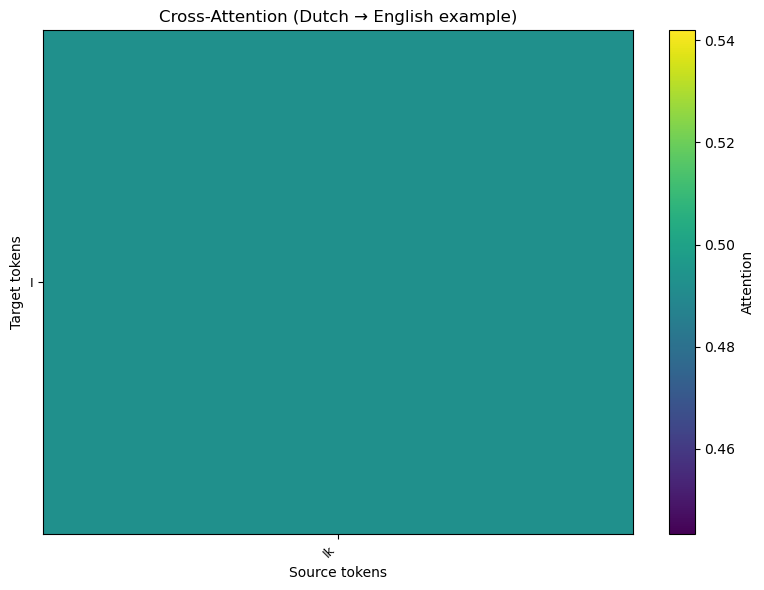

In [36]:
# --- Example Usage (Dutch → English) — safetensors-first, T5 fallback ---
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

try:
    model_name = "Helsinki-NLP/opus-mt-nl-en"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name, use_safetensors=True)
    is_t5 = False
except Exception as e:
    print("Marian (safetensors) unavailable — falling back to T5.\n", e)
    model_name = "google-t5/t5-small"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name, use_safetensors=True)
    is_t5 = True

example_src = "Ik"
if is_t5:
    example_src = "translate Dutch to English: " + example_src  # T5 needs a task prefix

visualize_cross_attention(
    model,
    tokenizer,
    example_src,
    forced_tgt_text=None,   # or: "This is a short example sentence."
    decoder_layer=-1,
    head=None,
    max_new_tokens=40,
    figsize=(8,6),
    title="Cross-Attention (Dutch → English example)"
)